### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
61               France            127              151            370   
45       Czech Republic            361              170            134   
141  Russian Federation            247              326             73   
99           Luxembourg            236              133            271   
155            Slovakia            196              293            116   
81              Ireland            313              118            165   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4  
68                           11.9  
61   

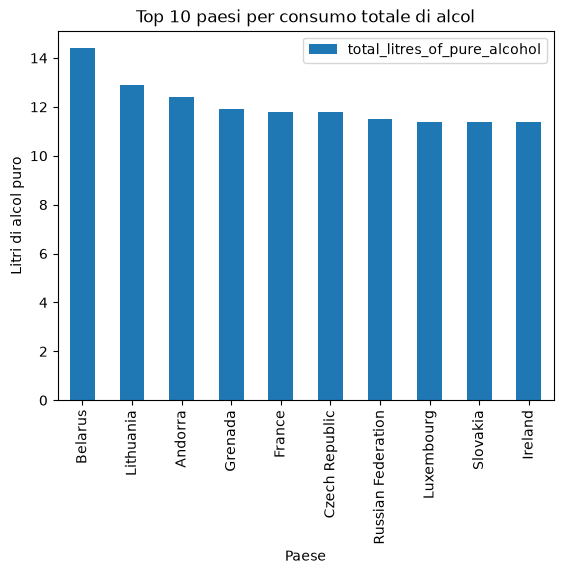

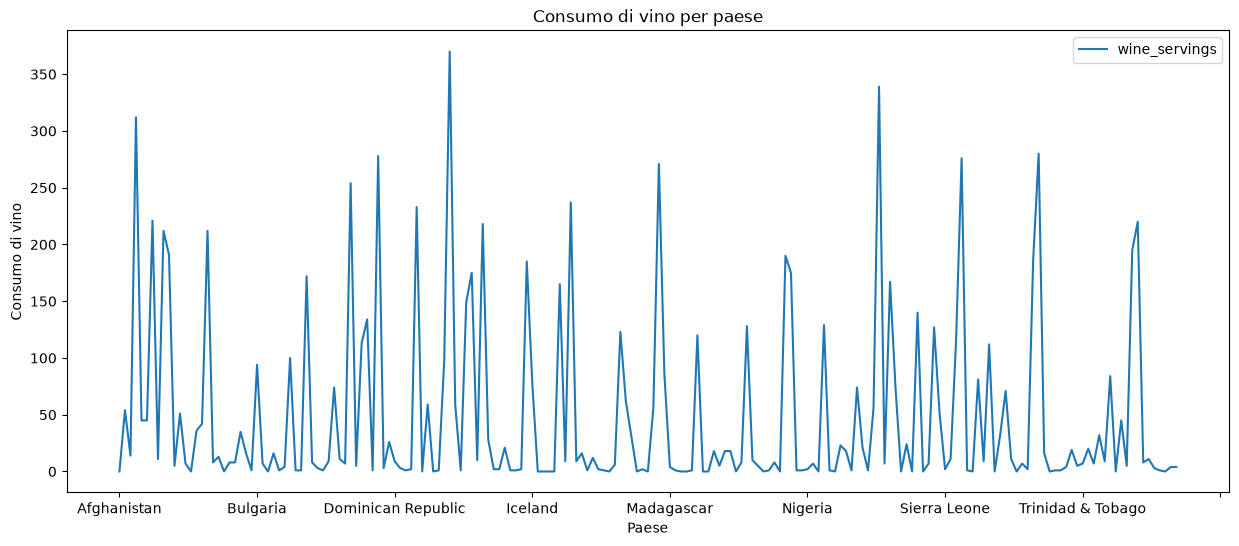

In [3]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

# Filtro i paesi
top10 = df.sort_values(
    by="total_litres_of_pure_alcohol",
    ascending=False
).head(10)

print(top10)

# Calcolo le medie
medie = df[["beer_servings", "wine_servings", "spirit_servings"]].mean()

print(medie)

# Creo la nuova colonna
df["alcohol_index"] = (
    df["beer_servings"] +
    df["wine_servings"] +
    df["spirit_servings"]
) / 3

df.head()

# Filtro il paese col più alto indice
paese_max = df.loc[df["alcohol_index"].idxmax()]

print(paese_max)

# Paesi con più di 100 birre
piu_100_birre = df[df["beer_servings"] > 100]

print(piu_100_birre)

import matplotlib.pyplot as plt

# Bar plot
top10.plot(
    x="country",
    y="total_litres_of_pure_alcohol",
    kind="bar"
)

plt.xlabel("Paese")
plt.ylabel("Litri di alcol puro")
plt.title("Top 10 paesi per consumo totale di alcol")

plt.show()

# Line plot
df_ordinato = df.sort_values("country")

df_ordinato.plot(
    x="country",
    y="wine_servings",
    kind="line",
    figsize=(15, 6)
)

plt.xlabel("Paese")
plt.ylabel("Consumo di vino")
plt.title("Consumo di vino per paese")

plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

             stipendio_medio  numero_offerte  stipendio_min  stipendio_max
job_country                                                               
Afghanistan              NaN              16            NaN            NaN
Albania         79472.500000             119        43200.0       157500.0
Algeria         44550.000000             111        44100.0        45000.0
Angola                   NaN              11            NaN            NaN
Argentina      105212.343750            8736        45000.0       222000.0
...                      ...             ...            ...            ...
Venezuela                NaN              69            NaN            NaN
Vietnam         90927.236364            2414        28000.0       200000.0
Yemen                    NaN              10            NaN            NaN
Zambia          90670.000000             104        90670.0        90670.0
Zimbabwe        67056.666667              81        47500.0        90670.0

[160 rows x 4 columns]
j

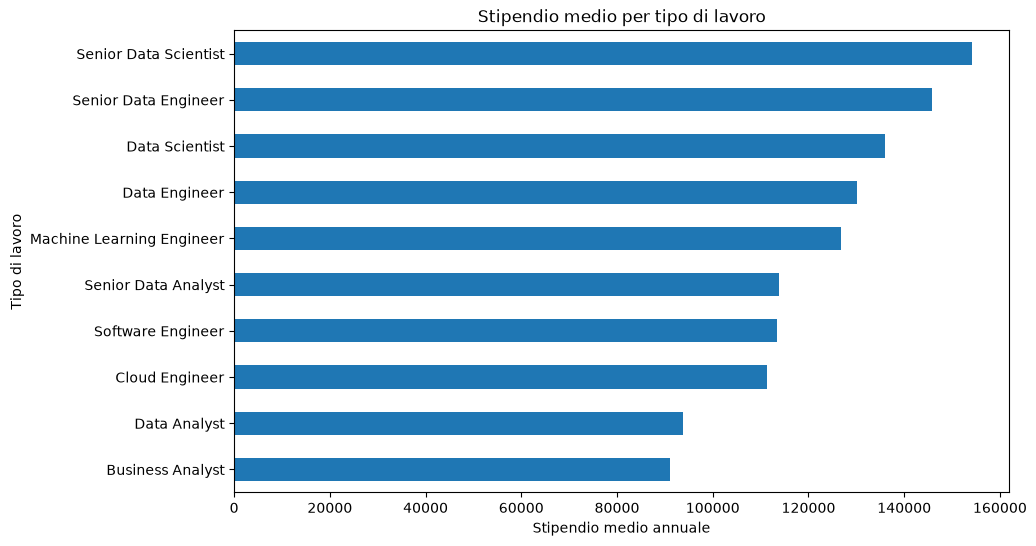

In [6]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Faccio l'analisi
analisi_paesi = df.groupby("job_country").agg(
    stipendio_medio=("salary_year_avg", "mean"),
    numero_offerte=("job_title_short", "size"),
    stipendio_min=("salary_year_avg", "min"),
    stipendio_max=("salary_year_avg", "max")
)

print(analisi_paesi)

# Calcolo e ordino gli stipendi per ruolo
stipendi_ruolo = (
    df.groupby("job_title_short")["salary_year_avg"]
    .mean()
    .sort_values(ascending=False)
)

print(stipendi_ruolo)

import matplotlib.pyplot as plt

# Creo il grafico a barre orizzontali
ax = stipendi_ruolo.plot(
    kind="barh",
    figsize=(10, 6)
)

ax.invert_yaxis()

plt.xlabel("Stipendio medio annuale")
plt.ylabel("Tipo di lavoro")
plt.title("Stipendio medio per tipo di lavoro")

plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

      conto_medio  numero_osservazioni  conto_minimo  conto_massimo
day                                                                
Fri     17.151579                   19          5.75          40.17
Sat     20.441379                   87          3.07          50.81
Sun     21.410000                   76          7.25          48.17
Thur    17.682742                   62          7.51          43.11
Sun
day
Sun     21.410000
Sat     20.441379
Thur    17.682742
Fri     17.151579
Name: total_bill, dtype: float64


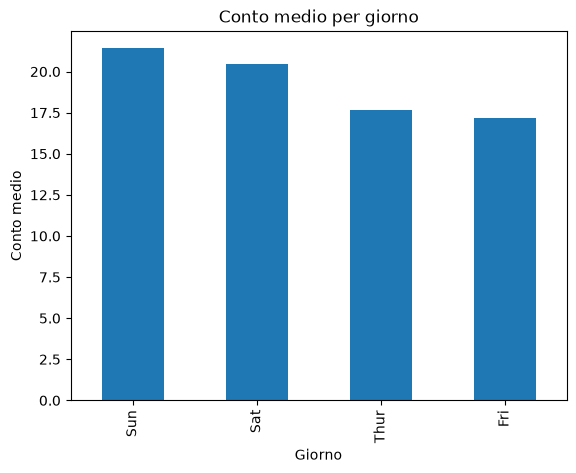

In [7]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

# Faccio l'analisi per giorno
analisi_giorni = df.groupby("day").agg(
    conto_medio=("total_bill", "mean"),
    numero_osservazioni=("total_bill", "size"),
    conto_minimo=("total_bill", "min"),
    conto_massimo=("total_bill", "max")
)

print(analisi_giorni)

# Creo la nuova colonna
df["conto_per_persona"] = df["total_bill"] / df["size"]

df.head()

# Trovo il giorno col conto medio più alto
conto_medio_giorni = df.groupby("day")["total_bill"].mean()

giorno_max = conto_medio_giorni.idxmax()

print(giorno_max)

# Ordino i dati per il grafico
conto_medio_ordinato = (
    df.groupby("day")["total_bill"]
    .mean()
    .sort_values(ascending=False)
)

print(conto_medio_ordinato)

import matplotlib.pyplot as plt

# Faccio il grafico a barre
conto_medio_ordinato.plot(
    kind="bar"
)

plt.xlabel("Giorno")
plt.ylabel("Conto medio")
plt.title("Conto medio per giorno")

plt.show()
